<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Creación de Características y Transformaciones Agrupadas 🏗️
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>


---
## El Objetivo de la Creación de Características 🎯

El objetivo de la **Ingeniería de Características (*Feature Engineering*)** es simplemente hacer que tus datos se adapten mejor al problema en cuestión.

Considera las medidas de **"temperatura aparente"** como el *índice de calor* o la *sensación térmica por viento (wind chill)*. Estas cantidades intentan medir la temperatura percibida por los seres humanos basándose en la temperatura del aire, la humedad y la velocidad del viento —variables que sí podemos medir directamente. Puedes pensar en la temperatura aparente como el resultado de una ingeniería de características: un intento de hacer que los datos observados sean más relevantes para lo que realmente nos interesa: *¡cómo se siente el clima afuera!*

Sueles realizar ingeniería de características para:
1. **Mejorar el rendimiento predictivo** de un modelo.
2. **Reducir las necesidades computacionales** o la cantidad de datos requeridos.
3. **Mejorar la interpretabilidad** de los resultados para la toma de decisiones.

---
### Un Principio Rector de Feature Engineering 🧭

> 📌 **Para que una característica sea útil, debe tener una relación con la variable objetivo que tu modelo sea capaz de aprender.**

Los modelos lineales, por ejemplo, solo son capaces de aprender relaciones estrictamente lineales. Por tanto, cuando usas un modelo lineal, tu meta es transformar las variables para que su relación con el objetivo sea lineal.

La idea clave aquí es que **una transformación que aplicas a una característica se convierte, en esencia, en parte del modelo mismo**:
- Imagina que intentas predecir el **Precio (*Price*)** de terrenos cuadrados a partir de la **Longitud (*Length*)** de uno de sus lados.
- Ajustar un modelo lineal directamente sobre `Length` produce malos resultados, ya que la relación no es lineal sino cuadrática ($Precio \propto Longitud^2$).

<div align="center">
  <img src="images/base_model.png" width="380" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="The Base Model">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 1:</b> El modelo lineal simple ajusta deficientemente cuando solo tiene la Longitud (Length) como característica.</p>
</div>

Sin embargo, si elevamos al cuadrado la característica `Length` para obtener el **Área (*Area = Length²*)**, creamos una relación lineal directa entre `Area` y `Price`.

Agregar `Area` al conjunto de características significa que este modelo lineal ahora puede ajustar una parábola. En otras palabras, **elevar una característica al cuadrado le otorgó al modelo lineal la capacidad de capturar efectos no lineales**.

<div align="center">
  <img src="images/extended_model.png" width="680" style="border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin: 10px;" alt="The Extended Model">
  <p style="color: #64748b; font-size: 0.9em; font-style: italic;"><b>Figura 2:</b> Izquierda: El ajuste sobre Área es perfectamente lineal. Derecha: Esto hace que el ajuste sobre Longitud sea una parábola ideal.</p>
</div>

Esto demuestra por qué existe un **retorno tan alto sobre el tiempo invertido en ingeniería de características**. Cualquier relación que tu modelo no pueda aprender por su arquitectura, tú mismo se la puedes suministrar mediante transformaciones adecuadas.

---
#### 1. Configuración del Entorno y Carga de Datasets 🛠️

En esta lección utilizaremos cuatro conjuntos de datos con diversos tipos de variables:
1. **US Traffic Accidents (`accidents.csv`)**: Accidentes de tránsito viales en EE.UU.
2. **1985 Automobiles (`autos.csv`)**: Especificaciones de motores y precios de vehículos.
3. **Concrete Formulations (`concrete.csv`)**: Resistencia a la compresión según formulación del hormigón.
4. **Customer Lifetime Value (`customer.csv`)**: Clientes y pólizas de una aseguradora.

In [1]:
import os
import urllib.parse
import urllib.request
import pandas as pd

# 🚀 Función de utilidad para cargar datasets de forma segura (Local o Google Colab)
def load_dataset(filename, module_name="06 - Feature Engineering"):
    candidates = [
        f"data/{filename}",
        f"{module_name}/data/{filename}",
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
            
    os.makedirs("data", exist_ok=True)
    target_path = f"data/{filename}"
    encoded_module = urllib.parse.quote(module_name)
    encoded_file = urllib.parse.quote(filename)
    url_main = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_module}/data/{encoded_file}"
    url_master = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_module}/data/{encoded_file}"
    
    print(f"📥 Descargando dataset '{filename}' desde el repositorio oficial...")
    try:
        urllib.request.urlretrieve(url_main, target_path)
    except Exception:
        urllib.request.urlretrieve(url_master, target_path)
    print(f"✅ Dataset '{filename}' cargado exitosamente.")
    return target_path

# Carga de los cuatro datasets para creación de características
accidents = pd.read_csv(load_dataset('accidents.csv', '06 - Feature Engineering'))
autos = pd.read_csv(load_dataset('autos.csv', '06 - Feature Engineering'))
concrete = pd.read_csv(load_dataset('concrete.csv', '06 - Feature Engineering'))
customer = pd.read_csv(load_dataset('customer.csv', '06 - Feature Engineering'))

print('✅ Datasets cargados exitosamente:')
print(f' - Accidents: {accidents.shape}')
print(f' - Autos:     {autos.shape}')
print(f' - Concrete:  {concrete.shape}')
print(f' - Customer:  {customer.shape}')


✅ Datasets cargados exitosamente:
 - Accidents: (100000, 29)
 - Autos:     (193, 25)
 - Concrete:  (1030, 9)
 - Customer:  (9134, 25)


---
### Consejos para Descubrir Nuevas Características 💡

- **Comprender las variables:** Consulta la documentación y diccionario de datos del dataset.
- **Investigar el dominio del problema (*Domain Knowledge*):** Si tu problema es predecir precios de viviendas, investiga sobre el sector inmobiliario. Wikipedia es un buen punto de partida, pero libros y [artículos de investigación](https://scholar.google.com/) suelen contener la información más precisa.
- **Utilizar visualización de datos:** La visualización puede revelar asimetrías severas en la distribución de una variable o relaciones complejas que podrían simplificarse.

---
### Transformaciones Matemáticas (*Mathematical Transforms*) 🧮

Las relaciones entre características numéricas suelen expresarse mediante fórmulas matemáticas descubiertas en tu investigación de dominio. En Pandas, puedes aplicar operaciones aritméticas a las columnas como si fueran números comunes.

#### Ejemplo en el Dataset de Automóviles (`autos`):
El **"stroke ratio"** (relación carrera-diámetro del pistón) es una métrica mecánica que evalúa la eficiencia frente al rendimiento deportivo de un motor:

In [2]:
# Calculamos la relación de carrera y diámetro (stroke ratio)
autos["stroke_ratio"] = autos.stroke / autos.bore
autos[["stroke", "bore", "stroke_ratio"]].head()


,stroke,bore,stroke_ratio
0,2.68,3.47,0.772334
1,2.68,3.47,0.772334
2,3.47,2.68,1.294776
3,3.40,3.19,1.065831
4,3.40,3.19,1.065831


Entre más compleja sea una combinación física o matemática, más difícil le resultará a un modelo aprenderla por sí mismo. Por ejemplo, la **cilindrada (*displacement*)** de un motor mide su potencia volumétrica total:

In [3]:
# Calculamos la cilindrada teórica del motor (displacement)
autos["displacement"] = (
    np.pi * ((0.5 * autos.bore) ** 2) * autos.stroke * autos.num_of_cylinders
)
autos[["bore", "stroke", "num_of_cylinders", "displacement"]].head()


,bore,stroke,num_of_cylinders,displacement
0,3.47,2.68,4,101.377976
1,3.47,2.68,4,101.377976
2,2.68,3.47,6,117.446531
3,3.19,3.40,4,108.695147
4,3.19,3.40,5,135.868934


#### Transformaciones de Reescalado y Normalización (Logaritmos y Raíces) 📉

La visualización de datos puede sugerir un "rediseño" de la forma de una variable mediante potencias o logaritmos. Por ejemplo, la distribución de la velocidad del viento (`WindSpeed`) en el dataset de accidentes viales es altamente asimétrica (*skewed*). En este caso, la transformación logarítmica $\log(1 + x)$ resulta sumamente efectiva para normalizarla:

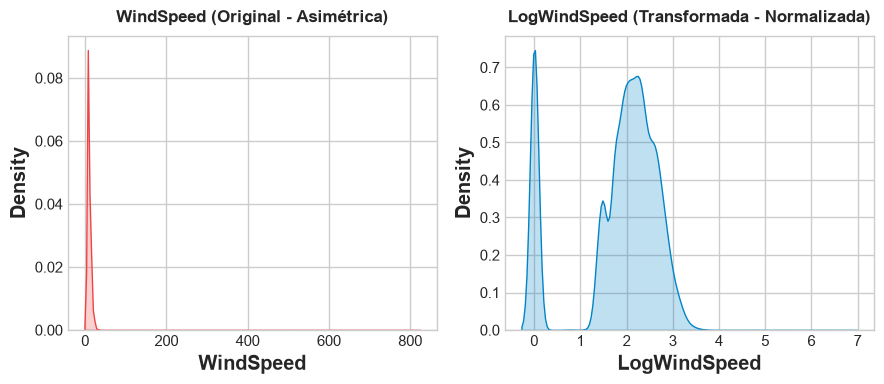

In [4]:
# Si la característica contiene valores 0.0, usamos np.log1p (log(1+x)) en lugar de np.log
accidents["LogWindSpeed"] = accidents.WindSpeed.apply(np.log1p)

# Graficamos la comparación antes y después de la transformación
fig, axs = plt.subplots(1, 2, figsize=(9, 4))
sns.kdeplot(accidents.WindSpeed, fill=True, color='#ef4444', ax=axs[0])
axs[0].set_title("WindSpeed (Original - Asimétrica)", fontsize=12, weight='bold')

sns.kdeplot(accidents.LogWindSpeed, fill=True, color='#0284c7', ax=axs[1])
axs[1].set_title("LogWindSpeed (Transformada - Normalizada)", fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


---
##### 🛠️ Práctica 1: Creando la Relación Peso-Potencia en Autos

En ingeniería automotriz, la relación peso-potencia (*curb_weight / horsepower*) es determinante para la aceleración del vehículo. Crea una nueva columna en `autos` llamada `'weight_to_hp'` que divida `curb_weight` entre `horsepower` y muestra las 5 marcas con el valor más bajo (vehículos más ágiles).

In [ ]:
# Escribe tu código aquí

# autos['weight_to_hp'] = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# Calculamos la relación peso-potencia
autos['weight_to_hp'] = autos['curb_weight'] / autos['horsepower']

# Mostramos los 5 vehículos más ligeros por caballo de fuerza
autos[['make', 'body_style', 'curb_weight', 'horsepower', 'weight_to_hp']].sort_values(by='weight_to_hp').head(5)
```
</details>

---


---
### Conteos y Agregaciones Booleanas (*Counts*) 🔢

Las características que describen la presencia o ausencia de algún elemento suelen presentarse en conjuntos (por ejemplo, factores de riesgo de una enfermedad o elementos viales cerca de un accidente).

Estas características serán binarias ($1$ para presente, $0$ para ausente) o booleanas (`True` / `False`). En Python, los booleanos se pueden sumar directamente como si fueran enteros (`True == 1`, `False == 0`).

##### Ejemplo en Accidentes de Tránsito (`accidents`):
Contamos cuántos elementos viales (señalizaciones, cruces, reductores) estaban presentes cerca del accidente:

In [5]:
# Lista de características de infraestructura vial
roadway_features = [
    "Amenity", "Bump", "Crossing", "GiveWay",
    "Junction", "NoExit", "Railway", "Roundabout",
    "Station", "Stop", "TrafficCalming", "TrafficSignal"
]

# Sumamos las características a lo largo de las columnas (axis=1)
accidents["RoadwayFeatures"] = accidents[roadway_features].sum(axis=1)
accidents[roadway_features + ["RoadwayFeatures"]].head(10)


,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,...,Roundabout,Station,Stop,TrafficCalming,TrafficSignal,RoadwayFeatures
0,False,False,False,False,False,False,...,False,False,False,False,False,0
1,False,False,False,False,False,False,...,False,False,False,False,False,0
2,False,False,False,False,False,False,...,False,False,False,False,False,0
3,False,False,False,False,False,False,...,False,False,False,False,False,0
4,False,False,False,False,False,False,...,False,False,False,False,False,0
5,False,False,False,False,True,False,...,False,False,False,False,False,1
6,False,False,False,False,False,False,...,False,False,False,False,False,0
7,False,False,True,False,False,False,...,False,False,False,False,True,2
8,False,False,True,False,False,False,...,False,False,False,False,True,2
9,False,False,False,False,False,False,...,False,False,False,False,False,0


También puedes utilizar métodos integrados del DataFrame como `.gt(0)` (*greater than zero*) para crear máscaras booleanas y contarlas.

#### Ejemplo en el Dataset de Hormigón (`concrete`):
Contamos cuántos componentes químicos activos están presentes en cada formulación de concreto:

In [6]:
# Lista de componentes químicos y agregados
components = [
    "Cement", "BlastFurnaceSlag", "FlyAsh", "Water",
    "Superplasticizer", "CoarseAggregate", "FineAggregate"
]

# Contamos cuántos componentes tienen una cantidad mayor a 0 (> 0)
concrete["Components"] = concrete[components].gt(0).sum(axis=1)
concrete[components + ["Components"]].head(10)


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,5
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,4


---
##### 🛠️ Práctica 2: Evaluando la Complejidad de la Formulación

Calcula la proporción de formulaciones en `concrete` que utilizan más de 4 componentes simultáneamente (`Components > 4`) y genera un gráfico de barras con el conteo de formulaciones según su número de componentes.

In [ ]:
# Escribe tu código aquí

# prop_complejas = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# Proporción de formulaciones complejas
prop_complejas = (concrete['Components'] > 4).mean()
print(f"Proporción de formulaciones con más de 4 componentes: {prop_complejas:.2%}")

# Gráfico de frecuencias
plt.figure(figsize=(7, 4))
sns.countplot(x=concrete['Components'], palette='Blues_r')
plt.title("Distribución del Número de Componentes por Mezcla", fontsize=13, weight='bold')
plt.xlabel("Cantidad de Componentes Activos", fontsize=11)
plt.ylabel("Frecuencia", fontsize=11)
plt.show()
```
</details>

---


---
###  Construcción y Descomposición de Cadenas (*Building-Up and Breaking-Down Features*) 🔤

A menudo tendrás cadenas de texto complejas que pueden dividirse provechosamente en componentes más simples. Ejemplos comunes:
- **Números de Identificación / IDs:** `'123-45-6789'`
- **Números Telefónicos:** `'(999) 555-0123'`
- **Direcciones:** `'1600 Amphitheatre Parkway, Mountain View, CA 94043'`
- **URLs:** `'http://www.google.com'`
- **Códigos de Producto:** `'0 36000 29145 2'`
- **Fechas y horas:** `'Mon Sep 30 07:06:05 2013'`

El accesor `.str` te permite aplicar métodos de cadenas directamente a las columnas. En el dataset de clientes (`customer`), la columna `Policy` contiene el tipo de póliza y el nivel de cobertura combinados:

In [7]:
# Creamos dos nuevas características dividiendo la columna 'Policy' por el espacio en blanco
customer[["Type", "Level"]] = (
    customer["Policy"]
    .str
    .split(" ", expand=True)
)
customer[["Policy", "Type", "Level"]].head(10)


,Policy,Type,Level
0,Corporate L3,Corporate,L3
1,Personal L3,Personal,L3
2,Personal L3,Personal,L3
3,Corporate L2,Corporate,L2
4,Personal L1,Personal,L1
5,Personal L3,Personal,L3
6,Corporate L3,Corporate,L3
7,Corporate L3,Corporate,L3
8,Corporate L3,Corporate,L3
9,Special L2,Special,L2


#### Fusión e Interacción de Características Categóricas
También puedes unir características simples en una variable compuesta si sospechas que existe una **interacción no aditiva** entre ellas:

In [8]:
# Combinamos marca y tipo de carrocería en una sola variable
autos["make_and_style"] = autos["make"] + "_" + autos["body_style"]
autos[["make", "body_style", "make_and_style"]].head()


,make,body_style,make_and_style
0,alfa-romero,convertible,alfa-romero_convertible
1,alfa-romero,convertible,alfa-romero_convertible
2,alfa-romero,hatchback,alfa-romero_hatchback
3,audi,sedan,audi_sedan
4,audi,sedan,audi_sedan


---
##### 🛠️ Práctica 3: Extracción y Combinación en Clientes de Seguros

Crea una nueva columna en `customer` llamada `'State_Employment'` que combine el estado de residencia (`State`) y el estado laboral (`EmploymentStatus`) separadas por un guion (ej. `'Washington-Employed'`). Muestra el conteo de las 5 combinaciones más frecuentes.

In [ ]:
# Escribe tu código aquí

# customer['State_Employment'] = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# Creamos la combinación categórica
customer['State_Employment'] = customer['State'] + "-" + customer['EmploymentStatus']

# Conteo de las 5 más frecuentes
customer['State_Employment'].value_counts().head(5)
```
</details>

---


---
### Transformaciones Agrupadas (*Group Transforms*) 📊

Las **transformaciones agrupadas** agregan información a través de múltiples filas agrupadas por alguna categoría. Te permiten crear características como: *"el ingreso promedio del estado de residencia de una persona"* o *"la proporción de películas estrenadas en fin de semana según su género"*.

Utilizando los métodos `.groupby()` y `.transform()` de Pandas, combinamos una variable categórica grupal con una numérica:

In [9]:
# Calculamos el ingreso promedio por estado (AverageIncome)
customer["AverageIncome"] = (
    customer.groupby("State")["Income"]
    .transform("mean")
)
customer[["State", "Income", "AverageIncome"]].head(10)


,State,Income,AverageIncome
0,Washington,56274,38122.733083
1,Arizona,0,37405.402231
2,Nevada,48767,38369.605442
3,California,0,37558.946667
4,Washington,43836,38122.733083
5,Oregon,62902,37557.283353
6,Oregon,55350,37557.283353
7,Arizona,0,37405.402231
8,Oregon,14072,37557.283353
9,Oregon,28812,37557.283353


Otras funciones de agregación útiles incluyen `"max"`, `"min"`, `"median"`, `"var"`, `"std"` y `"count"`. 

Por ejemplo, podemos calcular la **frecuencia relativa** con la que aparece cada estado en el conjunto de datos (*Frequency Encoding*):

In [10]:
# Codificación de frecuencia por estado (Frequency Encoding)
customer["StateFreq"] = (
    customer.groupby("State")["State"]
    .transform("count") / customer.State.count()
)
customer[["State", "StateFreq"]].head(10)


,State,StateFreq
0,Washington,0.087366
1,Arizona,0.186446
2,Nevada,0.096562
3,California,0.344865
4,Washington,0.087366
5,Oregon,0.284760
6,Oregon,0.284760
7,Arizona,0.186446
8,Oregon,0.284760
9,Oregon,0.284760


---
### ⚠️ Prevención de Data Leakage en Transformaciones Agrupadas 🧗

> **¡Atención!** Si estás utilizando particiones de entrenamiento y validación (*train/validation splits*), para preservar su independencia estadística es fundamental **calcular la agregación agrupada únicamente sobre el conjunto de entrenamiento (`df_train`)** y luego unirla (*merge*) al conjunto de validación (`df_valid`).

Veamos cómo realizar esta operación correctamente mediante `.drop_duplicates()` y `.merge()`:

In [11]:
# 1. Creamos las particiones de entrenamiento y validación
df_train = customer.sample(frac=0.5, random_state=0)
df_valid = customer.drop(df_train.index)

# 2. Calculamos el reclamo promedio por tipo de cobertura EXCLUSIVAMENTE en el conjunto de entrenamiento
df_train["AverageClaim"] = df_train.groupby("Coverage")["ClaimAmount"].transform("mean")

# 3. Unimos los valores calculados al conjunto de validación mediante merge por la columna 'Coverage'
df_valid = df_valid.merge(
    df_train[["Coverage", "AverageClaim"]].drop_duplicates(),
    on="Coverage",
    how="left",
)

df_valid[["Coverage", "AverageClaim"]].head(10)


,Coverage,AverageClaim
0,Basic,383.029600
1,Premium,635.912988
2,Basic,383.029600
3,Basic,383.029600
4,Premium,635.912988
5,Basic,383.029600
6,Basic,383.029600
7,Basic,383.029600
8,Basic,383.029600
9,Premium,635.912988


---
##### 🛠️ Práctica 4: Reclamo Mediano por Nivel Educativo sin Fuga de Información

Utilizando las mismas particiones `df_train` y `df_valid`, calcula la **mediana** de `ClaimAmount` agrupada por `Education` en `df_train` (columna `'MedianClaimByEdu'`) y trasládala a `df_valid` usando `.merge()`.

In [ ]:
# Escribe tu código aquí

# df_train['MedianClaimByEdu'] = ...
# df_valid = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1. Calculamos la mediana en entrenamiento
df_train['MedianClaimByEdu'] = df_train.groupby('Education')['ClaimAmount'].transform('median')

# 2. Mapeamos hacia validación mediante merge
tabla_edu = df_train[['Education', 'MedianClaimByEdu']].drop_duplicates()
df_valid = df_valid.merge(tabla_edu, on='Education', how='left')

# 3. Mostramos las primeras filas
df_valid[['Education', 'MedianClaimByEdu']].head(10)
```
</details>

---


---
### Guía Rápida: Creación de Características según el Tipo de Modelo 🚀

Es fundamental tener en cuenta las fortalezas y limitaciones del modelo que vas a emplear:

| Tipo de Modelo | Fortalezas Naturales | Limitaciones | Recomendación de Feature Engineering |
|---|---|---|---|
| **Modelos Lineales** | Sumas y diferencias ponderadas | No aprenden relaciones no lineales, multiplicaciones ni ratios. | Aplicar potencias, logaritmos, polinomios y productos explícitos. Normalizar variables. |
| **Ratios (Cocientes)** | Muy informativos en física/economía | Son sumamente difíciles de aprender para casi cualquier modelo. | Crear ratios explícitos (ej. peso/potencia, deuda/ingreso, ingreso/persona). |
| **Redes Neuronales** | Aproximan cualquier función continua | Sensibles a la escala y asimetrías extremas. | Escalar/normalizar características a rangos cercanos a 0 y transformar distribuciones sesgadas. |
| **Modelos Basados en Árboles** *(Random Forest, XGBoost, LightGBM)* | Invariantes a transformaciones monótonas de escala | Les cuesta agregar información dispersa entre múltiples columnas a la vez. | **Conteos de factores de riesgo**, agregaciones grupales y combinaciones categóricas explícitas. |

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>
